In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from google.colab import files

uploaded = files.upload()

Saving Marketing_Campaign.csv to Marketing_Campaign.csv


In [9]:
df = pd.read_csv("Marketing_Campaign.csv")

In [10]:
df.head()

,Customer ID,Age,Gender,City,Marketing Channel,Campaign Name,Campaign Cost,Impressions,Clicks,Leads,Conversions,Sales,Revenue,Campaign Date
0,1001,60,Male,Mumbai,LinkedIn,Flash Sale,9066,110079,3857,618,366,366,247416,2025-05-17
1,1002,21,Male,Hyderabad,Google Ads,Brand Awareness,6254,35768,3020,263,130,130,61230,2025-05-16
2,1003,27,Female,Delhi,Facebook,New Launch,6355,30668,1560,199,72,72,85968,2025-12-16
3,1004,44,Male,Pune,Facebook,Flash Sale,7293,118034,10424,1240,578,578,342176,2026-03-29
4,1005,24,Male,Delhi,LinkedIn,Brand Awareness,8531,101698,4854,985,542,542,390240,2026-04-30


In [11]:
df.shape

(500, 14)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Customer ID        500 non-null    int64 
 1   Age                500 non-null    int64 
 2   Gender             500 non-null    object
 3   City               500 non-null    object
 4   Marketing Channel  500 non-null    object
 5   Campaign Name      500 non-null    object
 6   Campaign Cost      500 non-null    int64 
 7   Impressions        500 non-null    int64 
 8   Clicks             500 non-null    int64 
 9   Leads              500 non-null    int64 
 10  Conversions        500 non-null    int64 
 11  Sales              500 non-null    int64 
 12  Revenue            500 non-null    int64 
 13  Campaign Date      500 non-null    object
dtypes: int64(9), object(5)
memory usage: 54.8+ KB


In [13]:
df.describe()

,Customer ID,Age,Campaign Cost,Impressions,Clicks,Leads,Conversions,Sales,Revenue
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,1250.500000,39.128000,5969.248000,64328.032000,3882.312000,644.674000,274.700000,274.700000,2.146561e+05
std,144.481833,12.984329,2370.909121,32144.858224,2555.893499,479.686575,220.786965,220.786965,2.023243e+05
min,1001.000000,18.000000,1047.000000,10004.000000,266.000000,45.000000,15.000000,15.000000,1.165500e+04
25%,1125.750000,27.750000,3946.250000,35739.750000,1794.250000,273.000000,115.750000,115.750000,7.558125e+04
50%,1250.500000,39.000000,5953.500000,62462.000000,3353.500000,515.500000,218.500000,218.500000,1.484100e+05
75%,1375.250000,51.000000,7603.500000,91083.250000,5561.500000,889.000000,369.000000,369.000000,2.957048e+05
max,1500.000000,60.000000,11582.000000,119818.000000,11043.000000,2650.000000,1203.000000,1203.000000,1.310944e+06


In [21]:

# Missing values
print(df.isnull().sum())

# Duplicate values
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Separate numerical and categorical columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Fill missing numerical values
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Convert date column
df['Campaign Date'] = pd.to_datetime(df['Campaign Date'])

# Final check
print(df.isnull().sum())
print(df.dtypes)
print(df.head())

Customer ID          0
Age                  0
Gender               0
City                 0
Marketing Channel    0
Campaign Name        0
Campaign Cost        0
Impressions          0
Clicks               0
Leads                0
Conversions          0
Sales                0
Revenue              0
Campaign Date        0
dtype: int64
Duplicate Rows: 0
Customer ID          0
Age                  0
Gender               0
City                 0
Marketing Channel    0
Campaign Name        0
Campaign Cost        0
Impressions          0
Clicks               0
Leads                0
Conversions          0
Sales                0
Revenue              0
Campaign Date        0
dtype: int64
Customer ID                   int64
Age                           int64
Gender                       object
City                         object
Marketing Channel            object
Campaign Name                object
Campaign Cost                 int64
Impressions                   int64
Clicks                  

<Axes: xlabel='Age', ylabel='Count'>

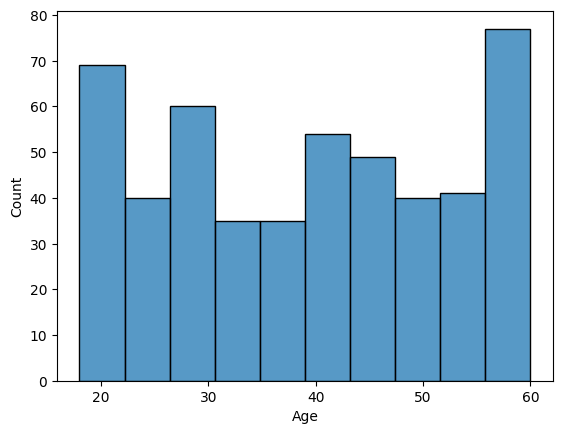

In [22]:
sns.histplot(df["Age"])

<Axes: xlabel='Gender', ylabel='count'>

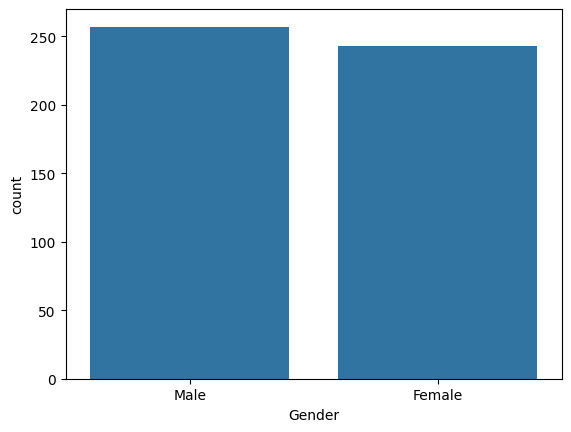

In [23]:
sns.countplot(x="Gender",data=df)

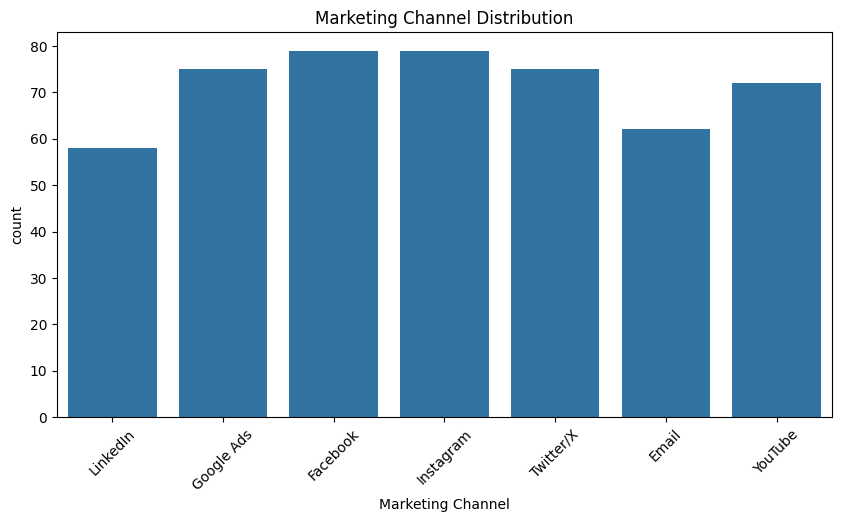

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(x="Marketing Channel", data=df)
plt.xticks(rotation=45)
plt.title("Marketing Channel Distribution")
plt.show()

<Axes: ylabel='Campaign Cost'>

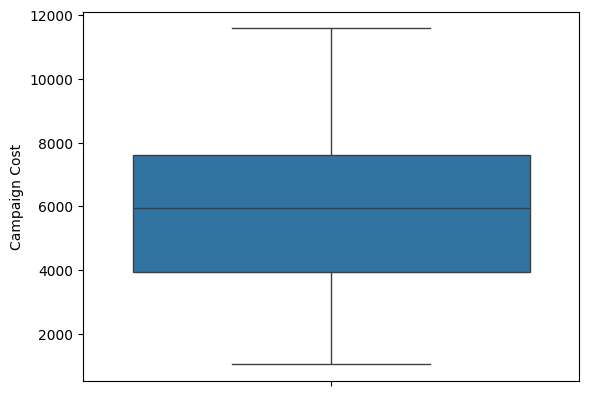

In [26]:
sns.boxplot(df["Campaign Cost"])

<Axes: xlabel='Revenue', ylabel='Count'>

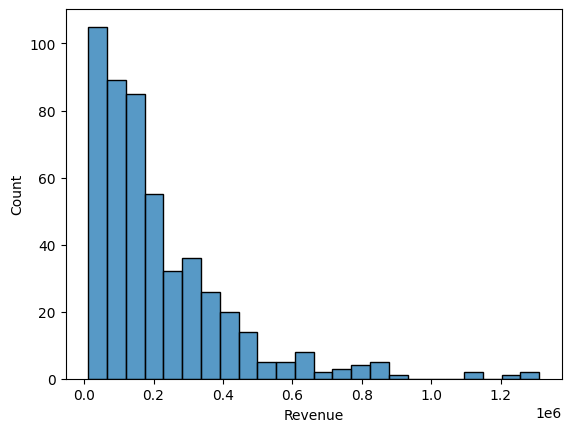

In [27]:
sns.histplot(df["Revenue"])

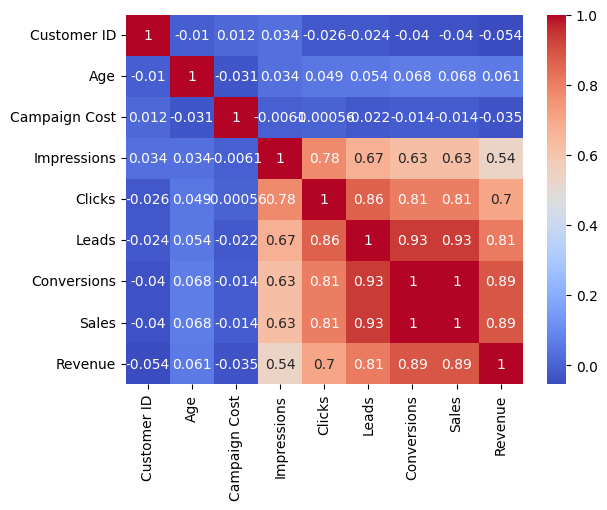

In [29]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [30]:
# Calculate totals
impressions = df["Impressions"].sum()
clicks = df["Clicks"].sum()
leads = df["Leads"].sum()
conversions = df["Conversions"].sum()
sales = df["Sales"].sum()

print(impressions)
print(clicks)
print(leads)
print(conversions)
print(sales)

32164016
1941156
322337
137350
137350


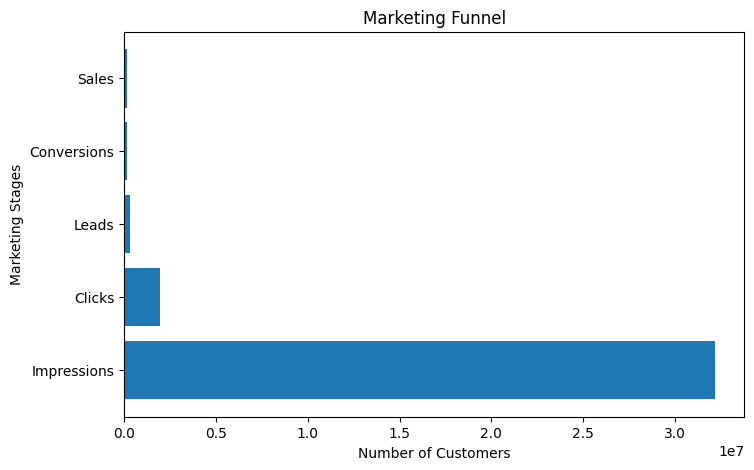

In [31]:
import matplotlib.pyplot as plt

stages = ["Impressions", "Clicks", "Leads", "Conversions", "Sales"]

values = [
    impressions,
    clicks,
    leads,
    conversions,
    sales
]

plt.figure(figsize=(8,5))

plt.barh(stages, values)

plt.title("Marketing Funnel")

plt.xlabel("Number of Customers")

plt.ylabel("Marketing Stages")

plt.show()

In [38]:
df["ROI"] = (df["Revenue"] - df["Campaign Cost"]) / df["Campaign Cost"]
df.groupby("Marketing Channel")["ROI"].mean()

,ROI
Marketing Channel,
Email,95.243281
Facebook,43.724919
Google Ads,34.268816
Instagram,39.606130
LinkedIn,26.741183
Twitter/X,47.264654
YouTube,24.912389


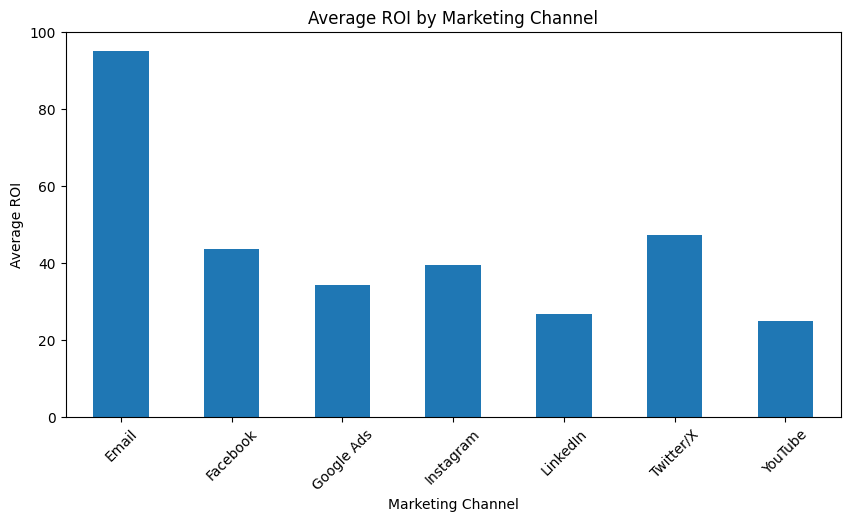

In [39]:
import matplotlib.pyplot as plt

roi = df.groupby("Marketing Channel")["ROI"].mean()

plt.figure(figsize=(10,5))
roi.plot(kind="bar")

plt.title("Average ROI by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Average ROI")
plt.xticks(rotation=45)
plt.show()

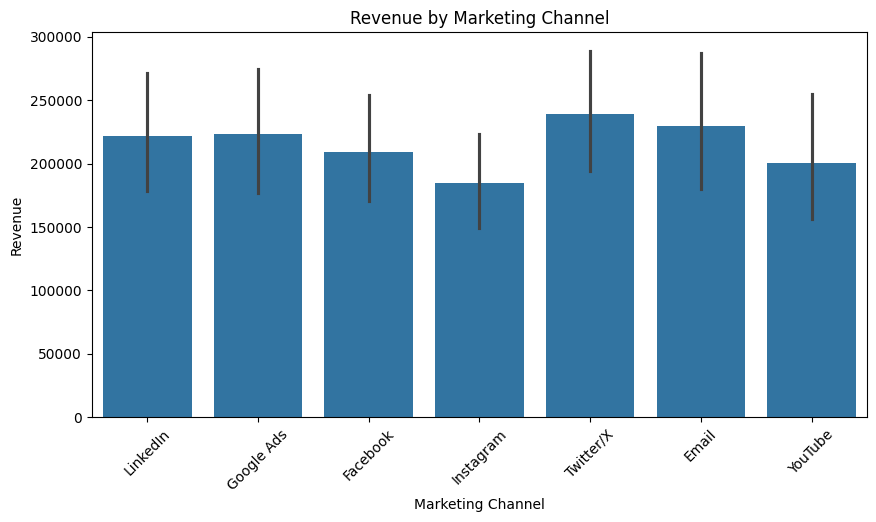

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x="Marketing Channel", y="Revenue", data=df)

plt.title("Revenue by Marketing Channel")
plt.xticks(rotation=45)
plt.show()

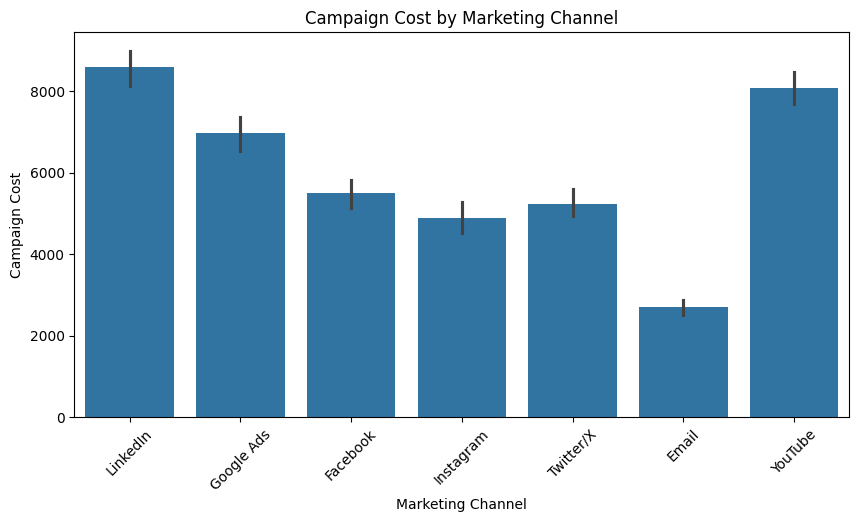

In [42]:
plt.figure(figsize=(10,5))
sns.barplot(x="Marketing Channel", y="Campaign Cost", data=df)

plt.title("Campaign Cost by Marketing Channel")
plt.xticks(rotation=45)
plt.show()

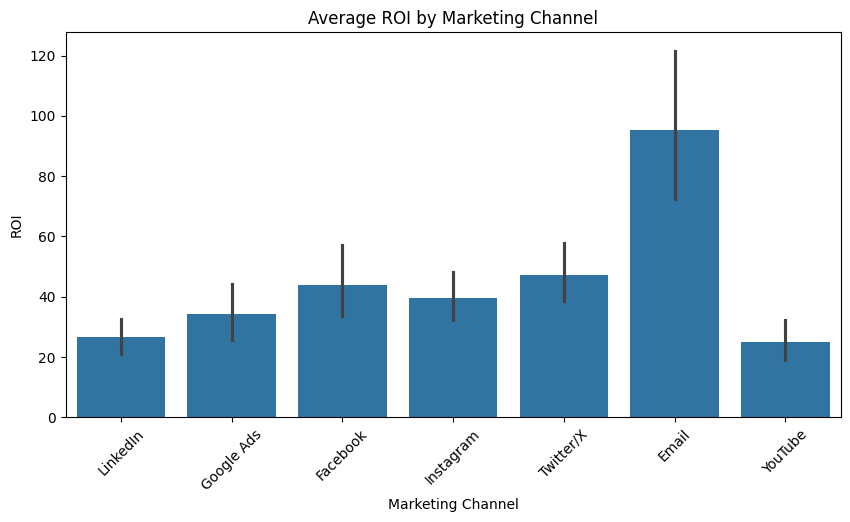

In [43]:
df["ROI"] = (df["Revenue"] - df["Campaign Cost"]) / df["Campaign Cost"]
plt.figure(figsize=(10,5))
sns.barplot(x="Marketing Channel", y="ROI", data=df)

plt.title("Average ROI by Marketing Channel")
plt.xticks(rotation=45)
plt.show()